In [1]:
import os
import numpy as np
import pickle

PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

X_train = np.load(os.path.join(PROJECT_ROOT, "data/X_train_phish.npy"))
y_train = np.load(os.path.join(PROJECT_ROOT, "data/y_train_phish.npy"))

X_test = np.load(os.path.join(PROJECT_ROOT, "data/X_test_phish.npy"))
y_test = np.load(os.path.join(PROJECT_ROOT, "data/y_test_phish.npy"))

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
with open(os.path.join(PROJECT_ROOT, "data/feature_phish.pkl"), "rb") as f:
    feature_names = pickle.load(f)

In [4]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

In [5]:
def create_episode(X, y, n_way=2, k_shot=5, q_query=10):
    classes = torch.unique(y)
    selected = classes[torch.randperm(len(classes))[:n_way]]

    support_x, support_y = [], []
    query_x, query_y = [], []

    for i, cls in enumerate(selected):
        idx = (y == cls).nonzero(as_tuple=True)[0]
        idx = idx[torch.randperm(len(idx))]

        support_idx = idx[:k_shot]
        query_idx = idx[k_shot:k_shot+q_query]

        support_x.append(X[support_idx])
        support_y.append(torch.full((k_shot,), i))

        query_x.append(X[query_idx])
        query_y.append(torch.full((q_query,), i))

    return (
        torch.cat(support_x),
        torch.cat(support_y),
        torch.cat(query_x),
        torch.cat(query_y)
    )

In [6]:
class Encoder(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def compute_prototypes(x, y):
    classes = torch.unique(y)
    return torch.stack([x[y==c].mean(0) for c in classes])

In [8]:
model = Encoder(X_train.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=0.001)

for ep in range(300):
    sx, sy, qx, qy = create_episode(X_train, y_train)

    se = model(sx)
    qe = model(qx)

    proto = compute_prototypes(se, sy)

    dist = ((qe.unsqueeze(1) - proto.unsqueeze(0))**2).sum(2)
    logits = -dist

    loss = torch.nn.CrossEntropyLoss()(logits, qy)

    opt.zero_grad()
    loss.backward()
    opt.step()

    if ep % 50 == 0:
        acc = (logits.argmax(1) == qy).float().mean()
        print(ep, loss.item(), acc.item())

0 0.3544708788394928 0.949999988079071
50 1.2868236808571965e-05 1.0
100 0.0015845762100070715 1.0
150 0.011335274204611778 1.0
200 0.002520077396184206 1.0
250 0.0015855462988838553 1.0


In [9]:
torch.save(model.state_dict(),
    os.path.join(PROJECT_ROOT, "models/fewshot_model_phish.pt"))

In [10]:
# Reload model (good practice even if already in memory)
model = Encoder(X_train.shape[1])
model.load_state_dict(
    torch.load(os.path.join(PROJECT_ROOT, "models/fewshot_model_phish.pt"))
)
model.eval()

Encoder(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
)

In [11]:
!pip install captum

In [12]:
from captum.attr import IntegratedGradients
import numpy as np
import pandas as pd

ig = IntegratedGradients(model)

In [17]:
import torch

sample = torch.tensor(X_test[0], dtype=torch.float32).unsqueeze(0)
sample.requires_grad = True

In [18]:
with torch.no_grad():
    output = model(sample)
    pred = torch.softmax(output, dim=1)

print("Original Prediction:", pred)

Original Prediction: tensor([[0.0109, 0.0176, 0.0268, 0.0089, 0.0301, 0.0120, 0.0094, 0.0154, 0.0380,
         0.0085, 0.0159, 0.0141, 0.0141, 0.0114, 0.0157, 0.0106, 0.0113, 0.0132,
         0.0097, 0.0137, 0.0114, 0.0129, 0.0213, 0.0119, 0.0173, 0.0134, 0.0186,
         0.0151, 0.0152, 0.0228, 0.0134, 0.0197, 0.0164, 0.0152, 0.0154, 0.0120,
         0.0101, 0.0262, 0.0139, 0.0094, 0.0231, 0.0079, 0.0194, 0.0219, 0.0195,
         0.0274, 0.0089, 0.0090, 0.0109, 0.0091, 0.0165, 0.0090, 0.0096, 0.0142,
         0.0220, 0.0122, 0.0107, 0.0194, 0.0148, 0.0069, 0.0262, 0.0251, 0.0248,
         0.0126]])


In [24]:
# get predicted class
output = model(sample)
pred_class = torch.argmax(output, dim=1).item()

# compute IG
attr_before = ig.attribute(sample, target=pred_class)

# convert ONCE
attr_before = attr_before.detach().numpy()[0]

table_before = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(attr_before)
}).sort_values("Importance", ascending=False)

table_before.head(10)

,Feature,Importance
6,URLCharProb,0.114466
21,IsHTTPS,0.103851
20,SpacialCharRatioInURL,0.094935
26,URLTitleMatchScore,0.076850
36,HasSocialNet,0.071902
4,CharContinuationRate,0.056464
13,LetterRatioInURL,0.048513
19,NoOfOtherSpecialCharsInURL,0.044120
32,HasDescription,0.039742
38,HasHiddenFields,0.039620


1) Top Feature Perturbation - slightly changed the most important features (top 3) identified by IG.

In [26]:
perturbed_1 = sample.clone().detach()

top_features = table_before.head(3)["Feature"].values

for f in top_features:
    idx = feature_names.index(f)
    perturbed_1[0, idx] += 0.1

# ✅ FIX: add target + safe conversion
attr_after_1 = ig.attribute(perturbed_1, target=pred_class)
attr_after_1 = attr_after_1.detach().cpu().numpy()[0]

drift_1 = np.mean(np.abs(attr_before - attr_after_1))
print("Attack1 Drift:", drift_1)

Attack1 Drift: 0.0012867872


2) Low Feature Perturbation - slightly changed the least important features (bottom 3)

In [28]:
perturbed_2 = sample.clone().detach()

low_features = table_before.tail(3)["Feature"].values

for f in low_features:
    idx = feature_names.index(f)
    perturbed_2[0, idx] += 0.2

# ✅ FIX: add target + safe conversion
attr_after_2 = ig.attribute(perturbed_2, target=pred_class)
attr_after_2 = attr_after_2.detach().cpu().numpy()[0]

drift_2 = np.mean(np.abs(attr_before - attr_after_2))
print("Attack2 Drift:", drift_2)

Attack2 Drift: 0.0009125207


3) Gradient Attack - changed input in the most sensitive direction using gradients.

In [30]:
sample_grad = sample.clone().detach().requires_grad_(True)

output = model(sample_grad)

# ✅ FIX: use specific class logit (not max)
loss = output[0, pred_class]

loss.backward()
grad = sample_grad.grad

perturbed_3 = sample + 0.1 * grad.sign()

# ✅ FIX: add target + safe conversion
attr_after_3 = ig.attribute(perturbed_3, target=pred_class)
attr_after_3 = attr_after_3.detach().cpu().numpy()[0]

drift_3 = np.mean(np.abs(attr_before - attr_after_3))
print("Attack3 Drift:", drift_3)

Attack3 Drift: 0.0044591036


4) Strong Targeted Perturbation - strongly changed the top important features with larger values.

In [32]:
perturbed_4 = sample.clone().detach()

target_features = table_before.head(3)["Feature"].values

for f in target_features:
    idx = feature_names.index(f)
    perturbed_4[0, idx] += 0.3

# ✅ FIX: add target + safe conversion
attr_after_4 = ig.attribute(perturbed_4, target=pred_class)
attr_after_4 = attr_after_4.detach().cpu().numpy()[0]

drift_4 = np.mean(np.abs(attr_before - attr_after_4))
print("Attack4 Drift:", drift_4)

Attack4 Drift: 0.003352913


In [33]:
results = pd.DataFrame({
    "Attack": ["Attack1", "Attack2", "Attack3", "Attack4"],
    "Drift": [drift_1, drift_2, drift_3, drift_4]
})

results

,Attack,Drift
0,Attack1,0.001287
1,Attack2,0.000913
2,Attack3,0.004459
3,Attack4,0.003353


In [34]:
results.to_csv(
    os.path.join(PROJECT_ROOT, "metrics/fewshot_attack_results.csv"),
    index=False
)

print("Few-shot results saved")

Few-shot results saved


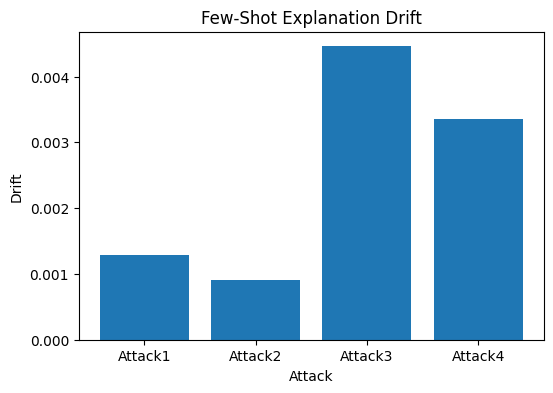

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["Attack"], results["Drift"])
plt.title("Few-Shot Explanation Drift")
plt.xlabel("Attack")
plt.ylabel("Drift")
plt.show()

The few-shot model was evaluated using four adversarial attacks.
Results show that gradient-based attack (Attack 3) causes the highest explanation drift,
indicating strong sensitivity to input perturbations.
Attacks on important features (Attack 1 and 4) also affect explanations,
while perturbing low-importance features (Attack 2) has minimal impact.
This demonstrates that few-shot models rely heavily on dominant features and
have unstable explanations due to limited training data.